In [1]:
using Plots, DifferentialEquations, LaTeXStrings
include("imode_sigmoid.jl")
using .ImodeSigmoid

## Spiking model
The simplest neuron model, with one sigmoid and two filters

In [2]:
function SpikingModel!(du,u,p,t)

	Iapp, Ithr, Igain, Ilin = p

	sig_pars = (Ithr=Ithr, Igain=Igain, Ilin=Ilin)
	
	If, Is = u

	du[1] = (-If - Is + Imode_sigmoid_eval(If, sig_pars) + Iapp) / τ_f
	du[2] = (-Is + If) / τ_s

end

SpikingModel! (generic function with 1 method)

## Bursting model
Full neuron model as implemented on chip
- 3 filters implementing 3 different timescales
- 2 sigmoids for fast and slow positive feedback
- Sigmoid gain inactivations by the slower timescale
- Gains on the low-pass filter inputs

In [ ]:
function BurstingModel_inact_gains!(du,u,p,t)

	Iapp, Ithr_f, Igain_f, Ilin_f, Ithr_s, Igain_s, Ilin_s, G_fDPI, G_sDPI, G_usDPI = p
	
	If, Is, Ius = u

	sigf_pars = (Ithr=Ithr_f, Igain=Igain_f-Is, Ilin=Ilin_f)
	sigs_pars = (Ithr=Ithr_s, Igain=Igain_s-Ius, Ilin=Ilin_s)

	du[1] = (-If + G_fDPI*(- Is - Ius + Imode_sigmoid_eval(If, sigf_pars, var_gain=true) + Imode_sigmoid_eval(Is, sigs_pars, var_gain=true) + Iapp)) / τ_f
	du[2] = (-Is + G_sDPI*If) / τ_s
	du[3] = (-Ius + G_usDPI*If) / τ_us

	# Currents need to be non-negative
	if If <= 0 && du[1] < 0
		du[1] = 0
	end

end

BurstingModel_inact_gains! (generic function with 1 method)

In [4]:
τ_f = 0.0001
τ_s = 0.02
τ_us = 0.4

Ithr_f = 150e-9
Igain_f = 700e-9
Ilin_f = 250e-9

Ithr_s = 110e-9
Igain_s = 250e-9
Ilin_s = 50e-9

G_fDPI = 1.0
G_sDPI = 1.0
G_usDPI = 1.0

1.0

## Spiking neuron simulation

In [ ]:
Tfinal = 2.
tspan = (0.0, Tfinal)

Iapp = 5e-7

x0 = [100e-9, 100e-9]

pars = (Iapp, Ithr_f, Igain_f, Ilin_f)

prob = ODEProblem(SpikingModel!, x0, tspan, pars)
sol = solve(prob, Rodas4P(), abstol=1e-15, reltol=1e-12)
plot(sol, xlabel="Time (s)", ylabel="Current (A)", label=[L"I_f" L"I_s"], size = (800, 400))

## Bursting neuron simulation

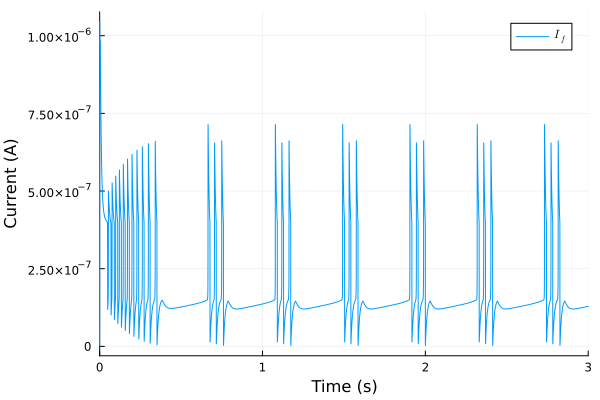

In [5]:
Tfinal = 3.
tspan = (0.0, Tfinal)

Iapp = 390e-9

x0 = [1e-9, 1e-9, 1e-9]

G_fDPI = 1.0

pars = (Iapp, Ithr_f, Igain_f, Ilin_f, Ithr_s, Igain_s, Ilin_s, G_fDPI, G_sDPI, G_usDPI)

prob = ODEProblem(BurstingModel_inact_gains!, x0, tspan, pars)
sol = solve(prob, Rodas4P(), abstol=1e-12, reltol=1e-9)
plot(sol, idxs=[1], xlabel="Time (s)", ylabel="Current (A)", label=[L"I_f" L"I_s" L"I_us"])

## Steady-state I-V curves of the neuron models

### Spiking model

In [ ]:
IV_Fast(I_eq) = I_eq - Imode_sigmoid_eval(I_eq, (Ithr=Ithr_f, Igain=Igain_f, Ilin=Ilin_f))
IV_Slow(I_eq) = 2*I_eq - Imode_sigmoid_eval(I_eq, (Ithr=Ithr_f, Igain=Igain_f, Ilin=Ilin_f))

plot([IV_Fast, IV_Slow], 0, 1e-6, legend = false, xlabel="Ieq (A)", ylabel="Iapp (A)", layout = (1, 2), size = (800, 400))

### Bursting model

In [ ]:
IV_SlowB(I_eq) = 2*I_eq - Imode_sigmoid_eval(I_eq, (Ithr=Ithr_f, Igain=Igain_f, Ilin=Ilin_f)) - Imode_sigmoid_eval(I_eq, (Ithr=Ithr_s, Igain=Igain_s, Ilin=Ilin_s))
IV_UslowB(I_eq) = 3*I_eq - Imode_sigmoid_eval(I_eq, (Ithr=Ithr_f, Igain=Igain_f, Ilin=Ilin_f)) - Imode_sigmoid_eval(I_eq, (Ithr=Ithr_s, Igain=Igain_s, Ilin=Ilin_s))

plot([IV_Fast, IV_SlowB, IV_UslowB], 0, 8e-7, legend = false, xlabel="Ieq (A)", ylabel="Iapp (A)", minorticks=true, layout = (1, 3), size = (1200, 400))